In [415]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [416]:
pre_process_df = pd.read_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\fe\featured_properties.csv")
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,features,luxury_score
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,...,0,0,0,0,1,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.105538
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,...,0,0,0,0,0,not available,Unfurnished,New Property,NaN,0.000000
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,...,1,1,0,1,1,east,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.359981
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0,1,0,0,0,west,Unfurnished,Relatively New,"['Maintenance Staff', 'Swimming Pool', 'No ope...",0.204557
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,...,0,1,0,0,0,east,Unfurnished,New Property,"['Power Back-up', 'Intercom Facility', 'Lift(s...",0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,...,0,0,0,1,0,north-east,Unfurnished,New Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,...,0,0,0,0,0,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.146893
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,...,0,0,0,0,0,north-east,Unfurnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.326750
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,...,0,1,0,1,0,east,Semi-Furnished,New Property,"['Centrally Air Conditioned', 'Security / Fire...",1.235554


### Outlier Detection and Removal

#### 1. Price In CR

In [417]:
pre_process_df['price_in_cr'].isnull().sum()

6

In [418]:
pre_process_df[pre_process_df['price_in_cr'].isnull()]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,features,luxury_score
267,B84332166,Independent House,https://www.99acres.com/7-bhk-bedroom-independ...,"Patel Nagar, Gurgaon",sector 15,NaN,NaN,1631 sqft (151.52 sqm) Plot Area,1631.0,NaN,...,0,0,0,1,0,north,Unfurnished,New Property,"['Water Storage', 'Rain Water Harvesting']",0.127547
3227,O59710486,Independent House,https://www.99acres.com/12-bhk-bedroom-indepen...,Malibu Towne,sector 47,NaN,NaN,7200 sqft (668.9 sqm) Plot Area,7200.0,NaN,...,1,0,1,1,0,not available,Unfurnished,New Property,"['High Ceiling Height', 'Maintenance Staff', '...",0.449632
3820,Q4798149,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"Nirvana Country, Gurgaon",sector 50,NaN,NaN,3750 sqft (348.39 sqm) Built-up Area,NaN,NaN,...,0,0,0,0,0,not available,Unfurnished,Relatively New,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.881387
4356,N68848866,Independent House,https://www.99acres.com/12-bhk-bedroom-indepen...,Malibu Towne,sector 47,NaN,NaN,7200 sqft (668.9 sqm) Plot Area,7200.0,NaN,...,1,1,1,1,0,west,Unfurnished,Moderately Old,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.092588
5355,P84897020,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"Block J Ashok Vihar phase 3 extension, Gurgaon",sector 3,NaN,NaN,900 sqft (83.61 sqm) Plot Area,900.0,NaN,...,0,0,1,0,0,not available,Unfurnished,Moderately Old,['No open drainage around'],0.004894
5589,D18376277,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"Sector 31, Gurgaon",sector 31,NaN,NaN,4518 sqft (419.74 sqm) Built-up Area,NaN,NaN,...,0,0,0,0,0,not available,Unfurnished,Relatively New,"['Power Back-up', 'Water Storage']",0.127547


In [419]:
pre_process_df = pre_process_df.dropna(subset=['price_in_cr','price_per_sqft'])

In [420]:
pre_process_df[['price_in_cr','price_per_sqft']].isna().sum()

price_in_cr       0
price_per_sqft    0
dtype: int64

In [421]:
pre_process_df['price_in_cr'].describe()

count    5974.000000
mean        5.334066
std         5.283274
min         0.170000
25%         2.280000
50%         3.450000
75%         6.490000
max        80.000000
Name: price_in_cr, dtype: float64

In [422]:
fig = px.histogram(pre_process_df['price_in_cr'])
fig

In [423]:
fig = px.box(data_frame= pre_process_df, x='price_in_cr')
fig

In [424]:
# Identify potential outliers using IQR method

Q1 = np.quantile(pre_process_df['price_in_cr'], 0.25)
Q3 = np.quantile(pre_process_df['price_in_cr'], 0.75)

IQR = Q3 - Q1

IQR

4.210000000000001

In [425]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-4.035000000000002 12.805000000000001


In [426]:
outliers = pre_process_df[(pre_process_df['price_in_cr'] < lower_bound) | (pre_process_df['price_in_cr'] > upper_bound)]
outliers

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,features,luxury_score
9,I84940266,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Emaar MGF The Vilas,sector 24,21.00,583333.0,360 sqft (33.45 sqm) Plot Area | 6800 sqft (63...,360.0,NaN,...,1,1,1,1,0,east,Furnished,Relatively New,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.265325
11,Z84139124,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"DLF Phase 2, Gurgaon",sector 25,16.00,33333.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,1,1,0,1,1,east,Semi-Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387
36,S84944800,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Unitech Espace,sector 50,15.00,46296.0,3240 sqft (301.01 sqm) Plot Area,3240.0,NaN,...,1,1,1,1,0,east,Unfurnished,Relatively New,"['Maintenance Staff', 'False Ceiling Lighting'...",0.652423
40,L81657752,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,Unitech Nirvana Birch Court,sector 50,20.00,44444.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0,1,0,0,0,east,Semi-Furnished,Old Property,"['Private Garden / Terrace', 'Maintenance Staf...",1.053687
43,E84700914,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Emaar MGF Marbella,sector 66,16.00,50794.0,3150 sqft (292.64 sqm) Plot Area,3150.0,NaN,...,1,1,0,0,0,north-east,Semi-Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'High Ceiling...",0.684097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923,V82811486,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,salcon the verandas,sector 54,19.85,33661.0,"5,986 sqft (556 sqm) Super Built-up Area",NaN,5986.0,...,0,1,0,1,0,north-west,Furnished,Old Property,"['Centrally Air Conditioned', 'Water purifier'...",1.364912
5925,N84063534,Independent House,https://www.99acres.com/9-bhk-bedroom-independ...,Luxurious villa 12mtr east facing park facing,sector 24,17.00,37778.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,1,1,1,1,0,east,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.887775
5942,I84167596,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,14.00,38889.0,3600 sqft (334.45 sqm) Plot Area,3600.0,NaN,...,0,1,1,0,0,north,Semi-Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.145334
5949,J84742264,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,Emaar MGF Marbella,sector 66,25.00,55556.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,1,1,0,1,1,east,Furnished,Moderately Old,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387


In [427]:
outliers.describe()

,price_in_cr,price_per_sqft,plot_area,super_built_up_area,built_up_area,carpet_area,bedrooms,bathrooms,floornum,study_room,servant_room,store_room,pooja_room,others,luxury_score
count,516.000000,516.000000,434.000000,36.000000,107.000000,83.000000,516.000000,516.000000,496.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000
mean,18.889709,49511.358527,4556.564516,4923.361111,6507.757009,6296.650602,6.317829,7.005814,3.796371,0.674419,0.912791,0.519380,0.736434,0.151163,0.993234
std,6.539067,58155.414252,2260.522169,1186.585694,7152.615928,8727.955247,4.305760,4.392178,4.456849,0.469046,0.282415,0.500109,0.440994,0.358555,0.386963
min,12.840000,2091.000000,350.000000,2686.000000,2200.000000,2000.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.837500,33333.000000,3240.000000,4126.000000,4050.000000,3301.500000,5.000000,5.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.881387
50%,17.000000,41666.500000,4500.000000,4817.000000,6000.000000,4200.000000,5.000000,6.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.074407
75%,21.000000,52469.000000,4518.000000,6000.000000,7650.000000,6950.000000,6.000000,7.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.363971
max,80.000000,619469.000000,29160.000000,7000.000000,76500.000000,61200.000000,48.000000,50.000000,41.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.364912


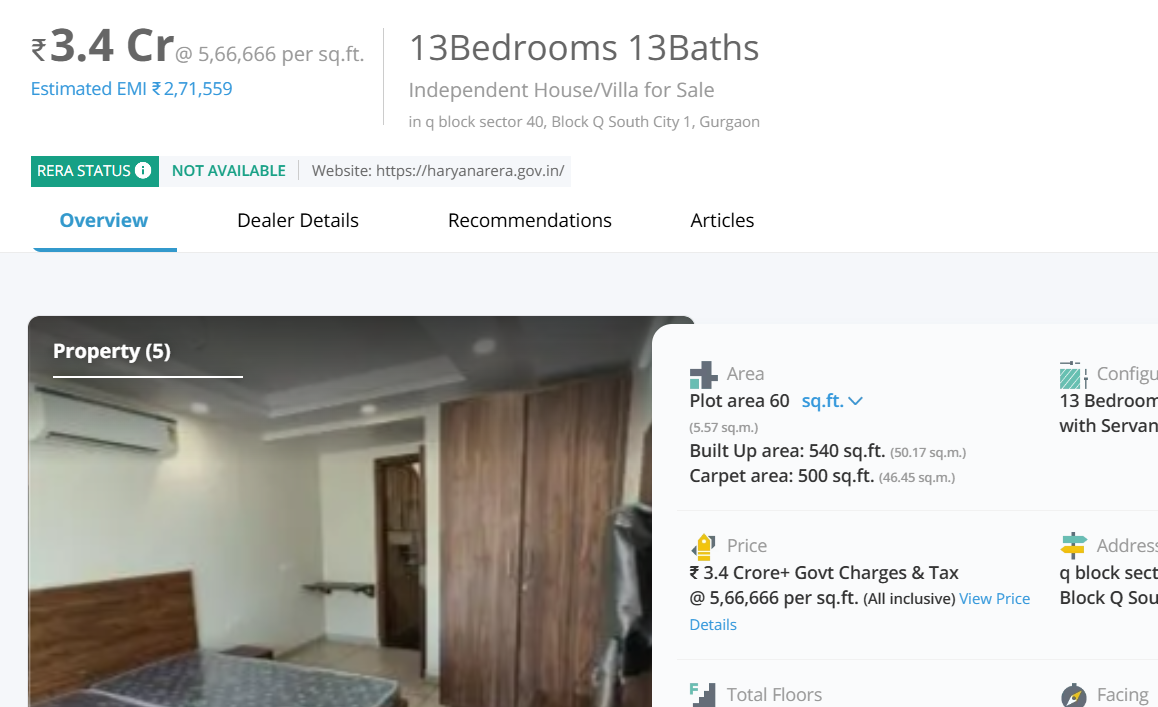

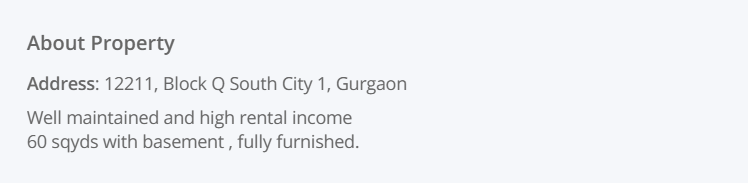

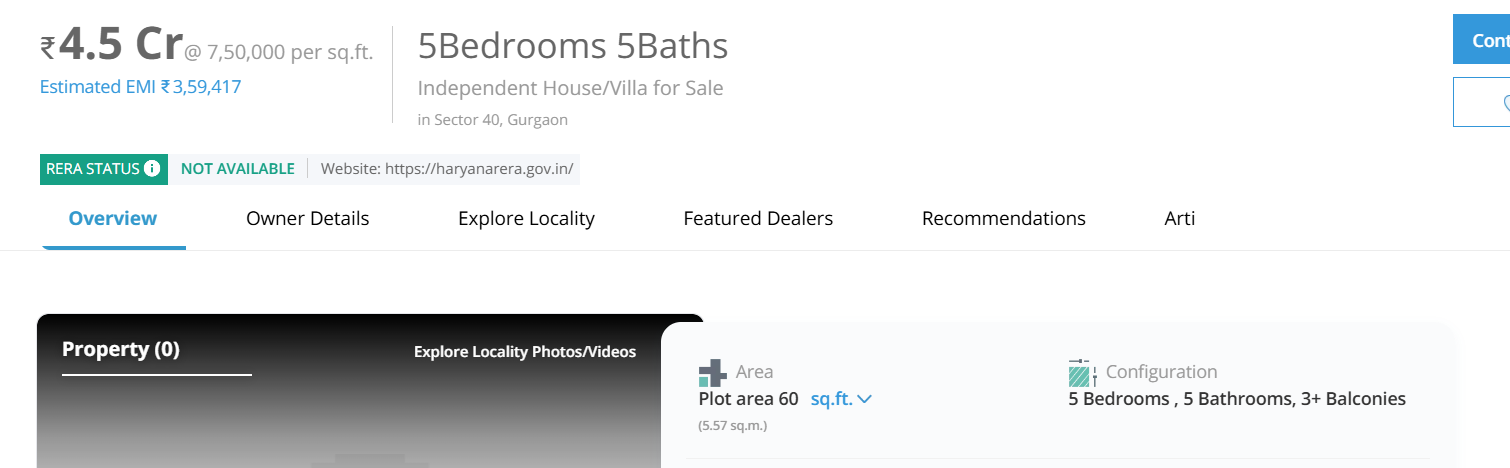

### 2. Total Area Sqft

In [428]:
def create_area_missing_flags(df):

    df = df.copy()

    area_cols = [
        'super_built_up_area',
        'built_up_area',
        'carpet_area',
        'plot_area'
    ]

    for col in area_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)

    return df

pre_process_df = create_area_missing_flags(pre_process_df)

In [429]:
def create_area_missing_flags(df):

    df = df.copy()

    area_cols = [
        'super_built_up_area',
        'built_up_area',
        'carpet_area',
        'plot_area'
    ]

    for col in area_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)

    return df

pre_process_df = create_area_missing_flags(pre_process_df)

In [430]:
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,others,facing,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,...,1,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.105538,1,1,0,1
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,...,0,not available,Unfurnished,New Property,NaN,0.000000,1,1,0,1
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,...,1,east,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.359981,1,1,0,1
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0,west,Unfurnished,Relatively New,"['Maintenance Staff', 'Swimming Pool', 'No ope...",0.204557,1,1,1,0
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,...,0,east,Unfurnished,New Property,"['Power Back-up', 'Intercom Facility', 'Lift(s...",0.000000,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,...,0,north-east,Unfurnished,New Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970,1,1,1,0
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,...,0,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.146893,0,1,1,1
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,...,0,north-east,Unfurnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.326750,0,1,1,1
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,...,0,east,Semi-Furnished,New Property,"['Centrally Air Conditioned', 'Security / Fire...",1.235554,0,1,1,1


In [431]:
def create_primary_area(df):

    df = df.copy()

    df["total_area_sqft"] = np.nan

    flat_mask = df["property_type"].isin(
        ["Flat", "Independent Builder Floor"]
    )

    df.loc[flat_mask, "total_area_sqft"] = \
        df.loc[flat_mask, "super_built_up_area"]

    house_mask = df["property_type"] == "Independent House"

    df.loc[house_mask, "total_area_sqft"] = \
        df.loc[house_mask, "plot_area"]

    return df

pre_process_df = create_primary_area(pre_process_df)

In [432]:
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,facing,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,...,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.105538,1,1,0,1,NaN
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,...,not available,Unfurnished,New Property,NaN,0.000000,1,1,0,1,NaN
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,...,east,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.359981,1,1,0,1,NaN
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,west,Unfurnished,Relatively New,"['Maintenance Staff', 'Swimming Pool', 'No ope...",0.204557,1,1,1,0,4500.0
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,...,east,Unfurnished,New Property,"['Power Back-up', 'Intercom Facility', 'Lift(s...",0.000000,1,0,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,...,north-east,Unfurnished,New Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970,1,1,1,0,900.0
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,...,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.146893,0,1,1,1,1656.0
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,...,north-east,Unfurnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.326750,0,1,1,1,1024.0
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,...,east,Semi-Furnished,New Property,"['Centrally Air Conditioned', 'Security / Fire...",1.235554,0,1,1,1,2650.0


In [433]:
pre_process_df['total_area_sqft'].isna().sum()

1093

In [434]:
(pre_process_df[["super_built_up_area",
        "built_up_area",
        "carpet_area",
        "plot_area"]]
    .isna()
    .all(axis=1)
).sum()

0

In [435]:
def fallback_area_creation(df):

    df = df.copy()

    fallback_cols = [
        "super_built_up_area",
        "built_up_area",
        "carpet_area",
        "plot_area"
    ]

    df["total_area_sqft"] = df["total_area_sqft"].fillna(
        df[fallback_cols].median(axis=1)
    )

    return df

pre_process_df = fallback_area_creation(pre_process_df)

In [436]:
pre_process_df['total_area_sqft'].isna().sum()

0

In [437]:
pre_process_df['total_area_sqft'].describe()

count     5974.000000
mean      2388.412789
std       1428.918586
min         42.000000
25%       1540.000000
50%       2100.000000
75%       2812.000000
max      29160.000000
Name: total_area_sqft, dtype: float64

In [438]:
fig = px.histogram(
    pre_process_df['total_area_sqft'],
    histnorm="density",
    title = "Distribution of total_area_sqft" 
)
fig.show()

In [439]:
pre_process_df.groupby("property_type")["total_area_sqft"].describe()

,count,mean,std,min,25%,50%,75%,max
property_type,,,,,,,,
Flat,2460.0,2122.227236,878.918793,456.0,1625.0,1930.0,2408.5,10000.0
Independent Builder Floor,1252.0,2586.895367,957.992921,300.0,1900.0,2430.5,3078.0,7659.0
Independent House,2262.0,2568.039788,1978.592991,42.0,1080.0,2250.0,3240.0,29160.0


In [440]:
pre_process_df.groupby("property_type")["total_area_sqft"].skew()

property_type
Flat                         2.141001
Independent Builder Floor    0.813185
Independent House            2.406704
Name: total_area_sqft, dtype: float64

In [441]:
# Calculate IQR for total_area_sqft

Q1 = pre_process_df['total_area_sqft'].quantile(0.25)
Q3 = pre_process_df['total_area_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Outlier bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 3 * IQR

print(lower_bound, upper_bound)

-368.0 6628.0


In [442]:
# Calculate IQR for total_area_sqft

Q1 = pre_process_df['total_area_sqft'].quantile(0.25)
Q3 = pre_process_df['total_area_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Outlier bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 3 * IQR

print(lower_bound, upper_bound)

-368.0 6628.0


In [443]:
outliers_area = pre_process_df[
    (pre_process_df['total_area_sqft'] < lower_bound) |
    (pre_process_df['total_area_sqft'] > upper_bound)
]
outliers_area

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,facing,furnishing_type,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft
92,W76422111,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Vipul Tatvam Villa,sector 48,21.00,31028.0,6768 sqft (628.77 sqm) Plot Area,6768.0,NaN,...,north-east,Semi-Furnished,Relatively New,"['Centrally Air Conditioned', 'Security / Fire...",1.360033,1,1,1,0,6768.0
214,Z57071432,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Experion Windchants,sector 112,14.49,19581.0,7400 sqft (687.48 sqm) Built-up Area,NaN,NaN,...,north-east,Semi-Furnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.202406,1,0,1,1,7400.0
332,A83457870,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Tata Primanti,sector 72,12.00,17142.0,7000 sqft (650.32 sqm) Built-up Area,NaN,NaN,...,north,Furnished,New Property,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,0,1,1,7000.0
375,V83889062,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"Malibu Town, Gurgaon",sector 47,24.50,30247.0,8100 sqft (752.51 sqm) Plot Area,8100.0,NaN,...,north-east,Semi-Furnished,Moderately Old,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,8100.0
399,H82779500,Flat,https://www.99acres.com/5-bhk-bedroom-apartmen...,adani m2k oyster grande,sector 102,9.40,12906.0,"7,283 sqft (677 sqm) Super Built-up Area",NaN,7283.0,...,north-east,Unfurnished,New Property,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,7283.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5608,G83969348,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Tata Primanti,sector 72,12.00,17142.0,7000 sqft (650.32 sqm) Plot Area,7000.0,NaN,...,east,Unfurnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,7000.0
5647,D84756666,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Vipul Tatvam Villa,sector 48,19.75,29259.0,6750 sqft (627.1 sqm) Plot Area,6750.0,NaN,...,north-east,Semi-Furnished,Old Property,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.119801,1,1,1,0,6750.0
5659,M77906185,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,International City by Sobha Phase 1,sector 109,18.00,24556.0,7330 sqft (680.98 sqm) Built-up Area,NaN,NaN,...,north-east,Unfurnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.119801,1,0,1,1,7330.0
5746,A84942576,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Experion Windchants,sector 112,14.52,19621.0,7400 sqft (687.48 sqm) Built-up Area,NaN,NaN,...,east,Unfurnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.054739,1,0,1,1,7400.0


In [444]:
extreme = pre_process_df[pre_process_df["total_area_sqft"] >= 15000]
extreme[["link","property_type","total_area_sqft","price_in_cr","price_per_sqft","sector"]]

,link,property_type,total_area_sqft,price_in_cr,price_per_sqft,sector
3067,https://www.99acres.com/7-bhk-bedroom-independ...,Independent House,15000.0,37.0,24666.0,sector 26
5118,https://www.99acres.com/5-bhk-bedroom-independ...,Independent House,29160.0,15.5,5315.0,sector 50


In [445]:
pre_process_df = pre_process_df[pre_process_df["total_area_sqft"] <= 15000]

In [446]:
fig = px.histogram(
    pre_process_df['total_area_sqft'],
    histnorm="density",
    title ="Distribution of total area sqft after removal of high values outliers"
)
fig.show()

### Price Per Sqft

In [447]:
pre_process_df['price_per_sqft'].describe()

count      5973.000000
mean      24533.423405
std       35098.161371
min        1815.000000
25%       12391.000000
50%       16244.000000
75%       27296.000000
max      750000.000000
Name: price_per_sqft, dtype: float64

In [448]:
fig = px.box(data_frame= pre_process_df, x='price_per_sqft')
fig

In [449]:
fig = px.histogram(
    pre_process_df['price_per_sqft'],
    histnorm="density"  
)
fig.show()

In [450]:
pre_process_df[pre_process_df["price_per_sqft"] > 100000][
    ["property_type","total_area_sqft","bedrooms","price_in_cr","price_per_sqft"]
]

,property_type,total_area_sqft,bedrooms,price_in_cr,price_per_sqft
9,Independent House,360.0,5,21.00,583333.0
164,Independent House,70.0,4,0.98,139985.0
186,Independent House,240.0,9,6.55,272916.0
193,Independent House,160.0,4,4.00,256250.0
367,Independent House,347.0,4,3.90,112391.0
...,...,...,...,...,...
5454,Independent House,168.0,5,5.25,312500.0
5457,Independent House,60.0,4,2.50,416666.0
5530,Independent Builder Floor,300.0,4,3.95,131666.0
5826,Independent House,135.0,6,5.60,414814.0


### Area vs Bedrooms

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



<Figure size 1200x500 with 0 Axes>

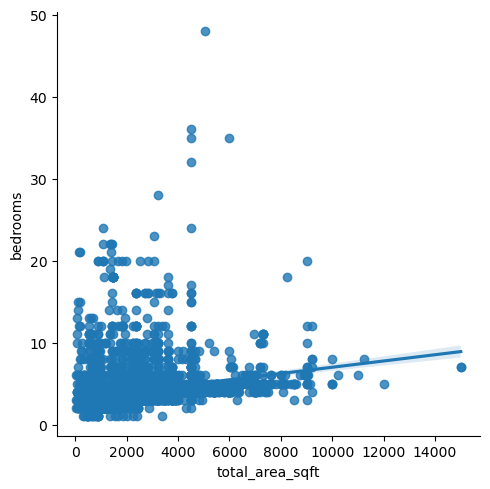

In [451]:
plt.figure(figsize=(12,5))
sns.lmplot(data= pre_process_df, x= 'total_area_sqft', y = 'bedrooms')

H72701303 - 540 sqft (50.17 sqm) Plot Area - 10 BHK Indepedent House 

X83996242 - 594 sqft (55.18 sqm) Plot Area - 11 BHK Indepdent house

At first glance, the property data appears genuine. However, certain records raise strong suspicion. Practically, it is extremely difficult to fit 11 bedrooms into such a small space, which suggests this entry could be erroneous or misleading.

Instead of analyzing each attribute in isolation (like price_per_sqft, area, price, or bedrooms), it is more meaningful to perform bivariate analysis — comparing two attributes together. In this case, analyzing area vs. bedroom count would help us identify unrealistic or extreme cases where the relationship between area and bedroom size does not make sense.

The rationale is that while individual values may look plausible on their own, the combination of features often reveals hidden outliers. For example:

A small area with an unusually high number of bedrooms (impractical).

A very large area with too few bedrooms (possibly data entry error).

By capturing such “dangerous” or inconsistent points through multivariate validation, we can better clean the dataset and improve the reliability of downstream metrics like price_per_sqft.

#### Bi-Variate Outlier Detection

In [452]:
pre_process_df["area_per_bedroom"] = (
    pre_process_df["total_area_sqft"] /
    pre_process_df["bedrooms"]
)

In [453]:
pre_process_df["area_per_bedroom"].describe()

count    5973.000000
mean      637.329593
std       295.866449
min         4.615385
25%       495.000000
50%       630.500000
75%       764.333333
max      3375.000000
Name: area_per_bedroom, dtype: float64

In [454]:
pre_process_df["area_per_bedroom"].quantile([0.01, 0.02, 0.05])

0.01     50.909091
0.02     81.000000
0.05    150.000000
Name: area_per_bedroom, dtype: float64

In [455]:
(pre_process_df["area_per_bedroom"] < 200).sum() / pre_process_df.shape[0] * 100

7.249288464758077

In [456]:
pre_process_df.loc[
    pre_process_df["area_per_bedroom"] < 275,
    ["property_type","total_area_sqft","bedrooms","price_in_cr","area_per_bedroom"]
]

,property_type,total_area_sqft,bedrooms,price_in_cr,area_per_bedroom
5,Independent House,1449.0,6,5.50,241.500
9,Independent House,360.0,5,21.00,72.000
23,Independent House,1449.0,20,8.75,72.450
24,Independent House,720.0,5,1.70,144.000
28,Independent House,1449.0,8,4.40,181.125
...,...,...,...,...,...
5924,Independent House,1449.0,6,5.50,241.500
5935,Independent House,1836.0,8,5.00,229.500
5954,Independent House,2367.0,9,6.50,263.000
5967,Independent House,1836.0,12,7.55,153.000


In [457]:
(pre_process_df["area_per_bedroom"] < 275).mean() * 100

11.451531893520844

In [458]:
pre_process_df.loc[
    pre_process_df["area_per_bedroom"] < 275,
    "property_type"
].value_counts(normalize=True)

property_type
Independent House            0.988304
Flat                         0.008772
Independent Builder Floor    0.002924
Name: proportion, dtype: float64

In [459]:
pre_process_df.shape

(5973, 32)

In [460]:
# Remove impossible
pre_process_df = pre_process_df[
    pre_process_df["area_per_bedroom"] >= 200
]

In [461]:
pre_process_df.shape

(5540, 32)

In [462]:
# Create density flag
pre_process_df["dense_house_flag"] = (
    (pre_process_df["area_per_bedroom"] < 275) &
    (pre_process_df["property_type"] == "Independent House")
).astype(int)

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



<Figure size 1200x500 with 0 Axes>

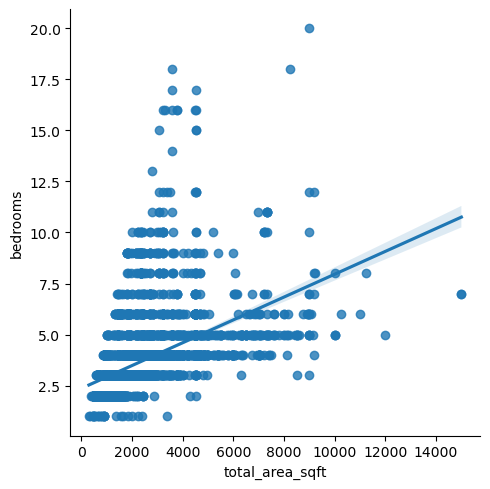

In [463]:
plt.figure(figsize=(12,5))
sns.lmplot(data= pre_process_df, x= 'total_area_sqft', y = 'bedrooms')

In [464]:
pre_process_df['price_per_sqft'].describe()

count      5540.000000
mean      20694.570758
std       17012.338422
min        2091.000000
25%       12222.000000
50%       15775.000000
75%       24306.000000
max      619469.000000
Name: price_per_sqft, dtype: float64

In [465]:
pre_process_df[
    pre_process_df["price_per_sqft"] > 100000
][["property_type","total_area_sqft","bedrooms","price_in_cr","price_per_sqft","sector","society"]]

,property_type,total_area_sqft,bedrooms,price_in_cr,price_per_sqft,sector,society
1329,Independent House,1000.0,5,12.00,120000.0,sector 50,Unitech Escape
2396,Independent House,6000.0,9,7.25,355392.0,sector 45,"Sector 45, Gurgaon"
3156,Independent House,7000.0,6,14.00,311111.0,sector 81,Bestech Park View Grand Spa
3174,Independent House,3260.0,4,5.90,240816.0,sector 82,Vatika Signature Villas
3760,Independent House,6900.0,5,6.70,231034.0,sector 70,Bptp Visionnaire
4536,Independent House,10000.0,5,35.00,619469.0,sector 26,DLF City Phase 1
4875,Independent House,3250.0,5,2.00,333333.0,sector 47,"Malibu Town, Gurgaon"
5031,Independent House,1750.0,3,1.20,150000.0,sector 105,Home Heaven Associates
5216,Independent House,1971.0,8,1.35,184931.0,sector 8,"Arjun Nagar, Gurgaon"


In [466]:
pre_process_df = pre_process_df[
    pre_process_df["price_per_sqft"] <= 100000
]

In [467]:
pre_process_df['price_per_sqft'].describe()

count      5531.000000
mean      20267.914663
std       12051.725386
min        2091.000000
25%       12222.000000
50%       15744.000000
75%       24271.000000
max      100000.000000
Name: price_per_sqft, dtype: float64

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



<Figure size 1200x500 with 0 Axes>

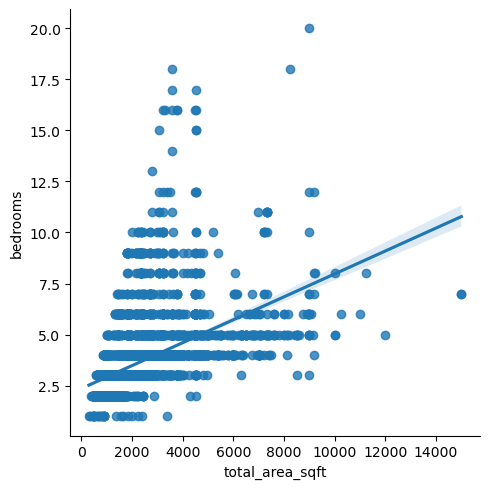

In [468]:
plt.figure(figsize=(12,5))
sns.lmplot(data= pre_process_df, x= 'total_area_sqft', y = 'bedrooms')

<Axes: xlabel='area_per_bedroom', ylabel='price_per_sqft'>

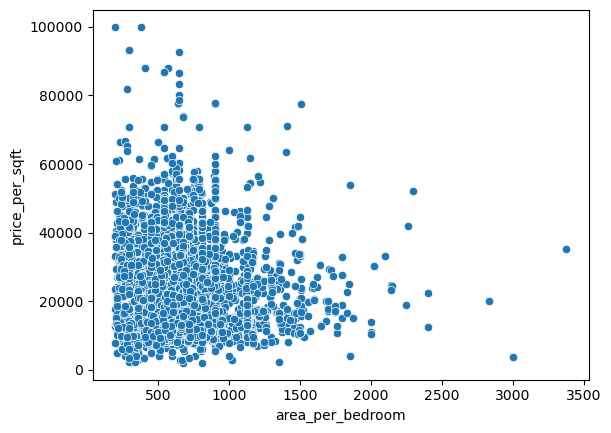

In [469]:
import seaborn as sns

sns.scatterplot(
    x="area_per_bedroom",
    y="price_per_sqft",
    data=pre_process_df
)

In [470]:
fig = px.histogram(
    pre_process_df['area_per_bedroom'],
    histnorm = "density",
    title = "Distribution of area_per_bedroom after removal of outliers"
)
fig.show()

##### Bedroom

In [471]:
pre_process_df['bedrooms'].describe()

count    5531.000000
mean        3.757006
std         1.584133
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: bedrooms, dtype: float64

In [472]:
pre_process_df['bedrooms'].unique()

array([ 4,  3,  6,  8,  2,  5,  1,  9,  7, 11, 16, 15, 10, 12, 14, 17, 18,
       13, 20], dtype=int64)

In [473]:
fig = px.box(
    data_frame= pre_process_df,
    x= ['bedrooms'],
)
fig.show()

In [474]:
fig = px.histogram(
    pre_process_df['bedrooms'],
    histnorm="density"
)
fig.show()

In [475]:
pre_process_df[pre_process_df['bedrooms'] > 15].sort_values('bedrooms',ascending=False)

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom,dense_house_flag
5579,W84006436,Independent House,https://www.99acres.com/20-bhk-bedroom-indepen...,"Sector 46, Gurgaon",sector 46,28.00,31111.0,9000 sqft (836.13 sqm) Plot Area,9000.0,NaN,...,Moderately Old,"['Water Storage', 'Visitor Parking', 'Waste Di...",0.346596,1,1,1,0,9000.0,450.000000,0
1929,T84163142,Independent House,https://www.99acres.com/18-bhk-bedroom-indepen...,"DLF Phase 2, Gurgaon",sector 25,18.50,51389.0,3600 sqft (334.45 sqm) Plot Area,3600.0,NaN,...,Moderately Old,"['Water Storage', 'Separate entry for servant ...",0.311914,1,1,1,0,3600.0,200.000000,1
3109,J84426212,Independent House,https://www.99acres.com/18-bhk-bedroom-indepen...,Spaze Palazo,sector 69,4.10,4979.0,8234 sqft (764.96 sqm) Plot Area,8234.0,NaN,...,New Property,NaN,0.000000,1,1,1,0,8234.0,457.444444,0
1549,K76578049,Independent House,https://www.99acres.com/17-bhk-bedroom-indepen...,"Garhi Harsaru, Gurgaon",sector 92,1.75,4861.0,3600 sqft (334.45 sqm) Plot Area,3600.0,NaN,...,Moderately Old,"['False Ceiling Lighting', 'Water Storage', 'R...",0.931272,1,1,1,0,3600.0,211.764706,1
4302,T84711596,Independent House,https://www.99acres.com/17-bhk-bedroom-indepen...,"A Block Sushant Lok Phase 1, Gurgaon",sector 43,17.00,37627.0,4518 sqft (419.74 sqm) Plot Area,4518.0,NaN,...,Relatively New,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970,1,1,1,0,4518.0,265.764706,1
324,P83858826,Independent House,https://www.99acres.com/16-bhk-bedroom-indepen...,Whispering Meadows,sector 43,25.00,66454.0,3762 sqft (349.5 sqm) Plot Area,3762.0,NaN,...,Relatively New,"['Water Storage', 'Piped-gas', 'Visitor Parkin...",0.346596,1,1,1,0,3762.0,235.125000,1
624,L84633814,Independent House,https://www.99acres.com/16-bhk-bedroom-indepen...,K block,sector 41,15.90,49074.0,3240 sqft (301.01 sqm) Plot Area,3240.0,NaN,...,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.291206,1,1,1,0,3240.0,202.500000,1
894,Q81658516,Independent House,https://www.99acres.com/16-bhk-bedroom-indepen...,"Sushant Lok Phase 1, Gurgaon",sector 43,22.00,61111.0,3600 sqft (334.45 sqm) Plot Area,3600.0,NaN,...,New Property,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,3600.0,225.000000,1
2457,U79858093,Independent House,https://www.99acres.com/16-bhk-bedroom-indepen...,"Sector 43, Gurgaon",sector 43,20.00,60883.0,3285 sqft (305.19 sqm) Plot Area,3285.0,NaN,...,New Property,['Waste Disposal'],0.245459,1,1,1,0,3285.0,205.312500,1
2459,N84254898,Independent House,https://www.99acres.com/16-bhk-bedroom-indepen...,"A Block Sushant Lok Phase 1, Gurgaon",sector 43,37.00,81895.0,4518 sqft (419.74 sqm) Plot Area,4518.0,NaN,...,Undefined,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,4518.0,282.375000,0


### Bathroom

In [476]:
pre_process_df['bathrooms'].describe()

count    5531.000000
mean        3.957151
std         1.724981
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max        20.000000
Name: bathrooms, dtype: float64

In [477]:
fig = px.box(
    data_frame= pre_process_df,
    x= ['bathrooms'],
)
fig.show()

In [478]:
fig = px.histogram(
    pre_process_df['bathrooms'],
    histnorm="density"
)
fig.show()

### Floornum

In [479]:
pre_process_df['floornum'].describe()

count    5444.000000
mean        5.786738
std         5.854557
min        -1.000000
25%         2.000000
50%         3.000000
75%         8.000000
max        45.000000
Name: floornum, dtype: float64

In [480]:
pre_process_df[pre_process_df['floornum'] > 35]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom,dense_house_flag
1144,T84077150,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,tulip monsella,sector 53,8.97,31016.0,"2,892 sqft (269 sqm) Super Built-up Area",NaN,2892.0,...,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,2892.0,964.000000,0
1357,K82012048,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Sector 104, Gurgaon",sector 104,4.68,16519.0,2833 sqft (263.19 sqm) Plot Area,2833.0,NaN,...,Undefined,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,2833.0,944.333333,0
1887,O84829490,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,ireo victory valley,sector 67,5.90,22163.0,"2,662 sqft (247 sqm) Super Built-up Area",NaN,2662.0,...,Moderately Old,"['Centrally Air Conditioned', 'Water purifier'...",1.266017,0,1,1,1,2662.0,887.333333,0
2884,M84243686,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,trump tower,sector 65,23.00,38016.0,"6,050 sqft (562 sqm) Super Built-up Area",NaN,6050.0,...,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,6050.0,1512.500000,0
3393,M83101316,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m latitude,sector 65,5.70,22809.0,"2,499 sqft (232 sqm) Super Built-up Area",NaN,2499.0,...,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,2499.0,833.000000,0
4919,Z84869388,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m heights,sector 65,3.95,19710.0,"2,004 sqft (186 sqm) Super Built-up Area",NaN,2004.0,...,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.686949,0,1,1,1,2004.0,668.000000,0
5102,P83511118,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m latitude,sector 65,5.75,23009.0,"2,499 sqft (232 sqm) Super Built-up Area",NaN,2499.0,...,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,2499.0,833.000000,0
5223,V84405798,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,trump tower,sector 65,23.00,38016.0,"6,050 sqft (562 sqm) Super Built-up Area",NaN,6050.0,...,Relatively New,"['Centrally Air Conditioned', 'Water purifier'...",1.364912,0,1,1,1,6050.0,1512.500000,0
5226,W83722248,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,m3m latitude,sector 65,7.50,26086.0,"2,875 sqft (267 sqm) Super Built-up Area",NaN,2875.0,...,Relatively New,"['Power Back-up', 'Feng Shui / Vaastu Complian...",0.127547,0,1,1,1,2875.0,718.750000,0
5545,Z85116662,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,m3m heights,sector 65,3.67,18995.0,"1,932 sqft (179 sqm) Super Built-up Area",NaN,1932.0,...,Relatively New,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",0.127547,0,1,1,1,1932.0,644.000000,0


### Luxury Score 

In [481]:
pre_process_df['luxury_score'].describe()

count    5531.000000
mean        0.685302
std         0.479654
min         0.000000
25%         0.200551
50%         0.703518
75%         1.126613
max         1.364912
Name: luxury_score, dtype: float64

In [482]:
fig = px.histogram(
    pre_process_df['luxury_score'],
    histnorm="density"
)
fig.show()

<Axes: xlabel='total_area_sqft', ylabel='price_in_cr'>

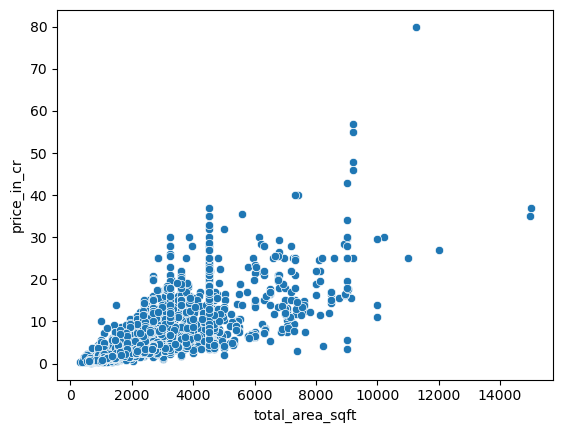

In [483]:
sns.scatterplot(x = pre_process_df['total_area_sqft'],y = pre_process_df['price_in_cr'])

In [484]:
pre_process_df.isnull().sum()

property_id                       0
property_type                     0
link                              0
society                           0
sector                            0
price_in_cr                       0
price_per_sqft                    0
areawithtype                      0
plot_area                      3861
super_built_up_area            2741
built_up_area                  4880
carpet_area                    4585
bedrooms                          0
bathrooms                         0
balcony                           0
floornum                         87
study_room                        0
servant_room                      0
store_room                        0
pooja_room                        0
others                            0
facing                            0
furnishing_type                   0
age_possession_category           0
features                        272
luxury_score                      0
super_built_up_area_missing       0
built_up_area_missing       

### FloorNum

In [485]:
pre_process_df['floornum'].describe()

count    5444.000000
mean        5.786738
std         5.854557
min        -1.000000
25%         2.000000
50%         3.000000
75%         8.000000
max        45.000000
Name: floornum, dtype: float64

In [486]:
pre_process_df['floornum'].isnull().sum()

87

In [487]:
pre_process_df[pre_process_df['floornum'].isnull()]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom,dense_house_flag
208,Q84013220,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Dayanand Colony, Gurgaon",sector 6,1.35,18000.0,750 sqft (69.68 sqm) Plot Area,750.0,NaN,...,Undefined,NaN,0.000000,1,1,1,0,750.0,250.000000,1
216,H83457942,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,DLF City Plots Phase 2,sector 25,12.00,43715.0,2745 sqft (255.02 sqm) Plot Area,2745.0,NaN,...,Old Property,"['Maintenance Staff', 'Water Storage', 'Park']",0.127547,1,1,1,0,2745.0,457.500000,0
263,B83775906,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Laxman Vihar Phase 2, Gurgaon",sector 3,0.75,5514.0,680 sqft (63.17 sqm) Plot Area | 1360 sqft (12...,680.0,NaN,...,New Property,"['Visitor Parking', 'Waste Disposal']",0.245459,1,1,0,0,680.0,226.666667,1
360,B81098539,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Sector 45, Gurgaon",sector 45,2.18,11874.0,1836 sqft (170.57 sqm) Plot Area,1836.0,NaN,...,New Property,"['Water Storage', 'Park', 'Visitor Parking', '...",0.346596,1,1,1,0,1836.0,612.000000,0
414,B83795520,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Unitech Deerwood Chase,sector 50,9.75,45139.0,2160 sqft (200.67 sqm) Plot Area,2160.0,NaN,...,Moderately Old,"['Feng Shui / Vaastu Compliant', 'Private Gard...",1.076032,1,1,1,0,2160.0,540.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5615,Q83778766,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"Golf Course Ext Road, Gurgaon",sector 61,28.00,44444.0,6300 sqft (585.29 sqm) Plot Area,6300.0,NaN,...,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,6300.0,1260.000000,0
5693,F84603358,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"Block J Pocket C Palam Vihar, Gurgaon",sector 1,12.50,27778.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,Old Property,"['Water Storage', 'Visitor Parking', 'Rain Wat...",0.127547,1,1,1,0,4500.0,900.000000,0
5710,U82130656,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Sector 41, Gurgaon",sector 41,8.00,49383.0,1620 sqft (150.5 sqm) Plot Area,1620.0,NaN,...,Relatively New,"['Feng Shui / Vaastu Compliant', 'Private Gard...",0.881387,1,1,1,0,1620.0,540.000000,0
5870,Z83648446,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"Maruti Kunj, Gurgaon",sector 105,1.10,9700.0,1134 sqft (105.35 sqm) Plot Area,1134.0,NaN,...,Old Property,NaN,0.000000,1,1,1,0,1134.0,283.500000,0


In [488]:
pre_process_df[pre_process_df['property_type'] == 'Independent House']['floornum'].median()

3.0

In [489]:
pre_process_df['floornum'] = pre_process_df['floornum'].fillna(pre_process_df['floornum'].median())


In [490]:
pre_process_df.isnull().sum()

property_id                       0
property_type                     0
link                              0
society                           0
sector                            0
price_in_cr                       0
price_per_sqft                    0
areawithtype                      0
plot_area                      3861
super_built_up_area            2741
built_up_area                  4880
carpet_area                    4585
bedrooms                          0
bathrooms                         0
balcony                           0
floornum                          0
study_room                        0
servant_room                      0
store_room                        0
pooja_room                        0
others                            0
facing                            0
furnishing_type                   0
age_possession_category           0
features                        272
luxury_score                      0
super_built_up_area_missing       0
built_up_area_missing       

### Age Possession

In [491]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2263
New Property          1495
Moderately Old        1070
Old Property           600
Undefined               97
Under Construction       6
Name: count, dtype: int64

In [492]:
pre_process_df[pre_process_df['age_possession_category']=='Undefined']

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom,dense_house_flag
46,P66222668,Independent House,https://www.99acres.com/1-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,2.15,13030.0,1650 sqft (153.29 sqm) Built-up Area,NaN,NaN,...,Undefined,NaN,0.000000,1,0,1,1,1650.0,1650.000000,0
208,Q84013220,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Dayanand Colony, Gurgaon",sector 6,1.35,18000.0,750 sqft (69.68 sqm) Plot Area,750.0,NaN,...,Undefined,NaN,0.000000,1,1,1,0,750.0,250.000000,1
247,G84372354,Independent House,https://www.99acres.com/1-bhk-bedroom-independ...,"Friends Colony, Gurgaon",sector 15,3.10,19897.0,1558 sqft (144.74 sqm) Built-up Area,NaN,NaN,...,Undefined,NaN,0.000000,1,0,1,1,1558.0,1558.000000,0
248,J82204076,Independent House,https://www.99acres.com/7-bhk-bedroom-independ...,"Saraswati Vihar, Gurgaon",sector 28,2.50,17857.0,1400 sqft (130.06 sqm) Built-up Area,NaN,NaN,...,Undefined,NaN,0.000000,1,0,1,1,1400.0,200.000000,1
356,H82379854,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,"Sector 10, Gurgaon",sector 10,0.65,13000.0,500 sqft (46.45 sqm) Plot Area,500.0,NaN,...,Undefined,NaN,0.000000,1,1,1,0,500.0,250.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5933,A82915952,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,Smart World Gems,sector 89,1.25,10451.0,1196 sqft (111.11 sqm) Built-up Area,NaN,NaN,...,Undefined,NaN,0.000000,1,0,1,1,1196.0,598.000000,0
5941,M82273028,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"Sector 79, Gurgaon",sector 79,3.00,12479.0,2404 sqft (223.34 sqm) Built-up Area | 2160 sq...,NaN,NaN,...,Undefined,NaN,0.000000,1,0,0,1,2282.0,570.500000,0
5943,G82564184,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,Signature Global City 92,sector 92,1.32,20465.0,1190 sqft (110.55 sqm) Plot Area | 645 sqft (5...,1190.0,NaN,...,Undefined,"['Feng Shui / Vaastu Compliant', 'Maintenance ...",0.127547,1,1,0,0,1190.0,396.666667,0
5947,A79824757,Independent House,https://www.99acres.com/7-bhk-bedroom-independ...,Assotech Blith,sector 99,7.25,27500.0,2600 sqft (241.55 sqm) Plot Area | 6300 sqft (...,2600.0,NaN,...,Undefined,"['Private Garden / Terrace', 'Centrally Air Co...",0.912169,1,0,1,0,2600.0,371.428571,0


In [493]:
def mode_based_imputation(row):
    if row['age_possession_category'] == 'Undefined':
        mode_value = pre_process_df[(pre_process_df['sector'] == row['sector']) & (pre_process_df['property_type'] == row['property_type'])]['age_possession_category'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['age_possession_category']

In [494]:
pre_process_df['age_possession_category'] = pre_process_df.apply(mode_based_imputation,axis=1)

In [495]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2289
New Property          1501
Moderately Old        1090
Old Property           615
Undefined               30
Under Construction       6
Name: count, dtype: int64

In [496]:
def mode_based_imputation2(row):
    if row['age_possession_category'] == 'Undefined':
        mode_value = pre_process_df[(pre_process_df['sector'] == row['sector'])]['age_possession_category'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['age_possession_category']

In [497]:
pre_process_df['age_possession_category'] = pre_process_df.apply(mode_based_imputation2,axis=1)

In [498]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2304
New Property          1502
Moderately Old        1090
Old Property           615
Undefined               14
Under Construction       6
Name: count, dtype: int64

In [499]:
def mode_based_imputation3(row):
    if row['age_possession_category'] == 'Undefined':
        mode_value = pre_process_df[(pre_process_df['property_type'] == row['property_type'])]['age_possession_category'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['age_possession_category']

In [500]:
pre_process_df['age_possession_category'] = pre_process_df.apply(mode_based_imputation3,axis=1)

In [501]:
pre_process_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2318
New Property          1502
Moderately Old        1090
Old Property           615
Under Construction       6
Name: count, dtype: int64

In [502]:
pre_process_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5531 entries, 0 to 5979
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   property_id                  5531 non-null   object 
 1   property_type                5531 non-null   object 
 2   link                         5531 non-null   object 
 3   society                      5531 non-null   object 
 4   sector                       5531 non-null   object 
 5   price_in_cr                  5531 non-null   float64
 6   price_per_sqft               5531 non-null   float64
 7   areawithtype                 5531 non-null   object 
 8   plot_area                    1670 non-null   float64
 9   super_built_up_area          2790 non-null   float64
 10  built_up_area                651 non-null    float64
 11  carpet_area                  946 non-null    float64
 12  bedrooms                     5531 non-null   int64  
 13  bathrooms              

In [505]:
pre_process_df.shape

(5531, 33)

In [504]:
pre_process_df

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,age_possession_category,features,luxury_score,super_built_up_area_missing,built_up_area_missing,carpet_area_missing,plot_area_missing,total_area_sqft,area_per_bedroom,dense_house_flag
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,...,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.105538,1,1,0,1,1800.0,450.000000,0
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,...,New Property,NaN,0.000000,1,1,0,1,2700.0,900.000000,0
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,...,Relatively New,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.359981,1,1,0,1,4000.0,1000.000000,0
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,Relatively New,"['Maintenance Staff', 'Swimming Pool', 'No ope...",0.204557,1,1,1,0,4500.0,1125.000000,0
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,...,New Property,"['Power Back-up', 'Intercom Facility', 'Lift(s...",0.000000,1,0,1,1,2002.0,667.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5974,O84302638,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Central Park Flower Valley Fleur Villas,sector 33,7.15,31777.0,2250 sqft (209.03 sqm) Plot Area | 2919 sqft (...,2250.0,NaN,...,Relatively New,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.973420,1,0,0,0,2250.0,562.500000,0
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,...,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.146893,0,1,1,1,1656.0,552.000000,0
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,...,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.326750,0,1,1,1,1024.0,512.000000,0
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,...,New Property,"['Centrally Air Conditioned', 'Security / Fire...",1.235554,0,1,1,1,2650.0,662.500000,0


In [ ]:
pre_process_df = pre_process_df[[
        'property_type','society', 'sector', 'price_in_cr', 'price_per_sqft',
        'total_area_sqft', 'bedrooms', 'bathrooms', 'balcony', 'floornum',
        'study_room', 'servant_room', 'store_room', 'pooja_room', 'others',
        'facing', 'furnishing_type','age_possession_category', 'luxury_score','features'
        'area_per_bedroom'
    ]]

In [414]:
pre_process_df.to_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\pp\preprocessed_properties_for_viz.csv",index= False)